# **Assessment 8 - K-Means vs. DBSCAN: Choosing the Right Clustering Algorithm**
**Written by:** Ulrik Gabryel Favorada, Sam Dominique Punzalan, Thom Daniel Yutuc

## **Part 1 — Data Preparation**

In [62]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm # dagdag
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors # dagdag
from sklearn.cluster import DBSCAN # dagdag
from sklearn.metrics import silhouette_samples # dagdag
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score # dagdag

***Load the data, select and clean the six features, and scale them. Report how many rows were removed due to missing values.***

In [15]:
# load dataset and check shape
df = pd.read_csv("CC GENERAL.csv")

print(f"Features: {df.shape[1]}")
print(f"Database Shape: {df.shape}")

Features: 18
Database Shape: (8950, 18)


In [16]:
# Select BALANCE, PURCHASES, CASH_ADVANCE, CREDIT_LIMIT, PAYMENTS, MINIMUM_PAYMENT
df_select = df[["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "MINIMUM_PAYMENTS"]]
df_select

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS
0,40.900749,95.40,0.000000,1000.0,201.802084,139.509787
1,3202.467416,0.00,6442.945483,7000.0,4103.032597,1072.340217
2,2495.148862,773.17,0.000000,7500.0,622.066742,627.284787
3,1666.670542,1499.00,205.788017,7500.0,0.000000,NaN
4,817.714335,16.00,0.000000,1200.0,678.334763,244.791237
...,...,...,...,...,...,...
8945,28.493517,291.12,0.000000,1000.0,325.594462,48.886365
8946,19.183215,300.00,0.000000,1000.0,275.861322,NaN
8947,23.398673,144.40,0.000000,1000.0,81.270775,82.418369
8948,13.457564,0.00,36.558778,500.0,52.549959,55.755628


In [17]:
# Check dataset for missing values
df_select.isna().sum()

BALANCE               0
PURCHASES             0
CASH_ADVANCE          0
CREDIT_LIMIT          1
PAYMENTS              0
MINIMUM_PAYMENTS    313
dtype: int64

In [27]:
# Drops 314 rows with missing values
df_select = df_select.dropna()

In [28]:
df_select.isna().sum()

BALANCE             0
PURCHASES           0
CASH_ADVANCE        0
CREDIT_LIMIT        0
PAYMENTS            0
MINIMUM_PAYMENTS    0
dtype: int64

In [29]:
# Check for potential outliers (all features contain potential outliers)
df_select.describe()

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS
count,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000,8636.000000
mean,1601.224893,1025.433874,994.175523,4522.091030,1784.478099,864.304943
std,2095.571300,2167.107984,2121.458303,3659.240379,2909.810090,2372.566350
min,0.000000,0.000000,0.000000,50.000000,0.049513,0.019163
25%,148.095189,43.367500,0.000000,1600.000000,418.559237,169.163545
50%,916.855459,375.405000,0.000000,3000.000000,896.675701,312.452292
75%,2105.195853,1145.980000,1132.385490,6500.000000,1951.142090,825.496463
max,19043.138560,49039.570000,47137.211760,30000.000000,50721.483360,76406.207520


In [35]:
# Scale Time and Amount
df_scaled = df_select.copy()

scaler = StandardScaler()
df_scaled[df_select.columns] = scaler.fit_transform(df_select)

***Plot the distribution of each feature. Comment on skewness and potential outliers.***

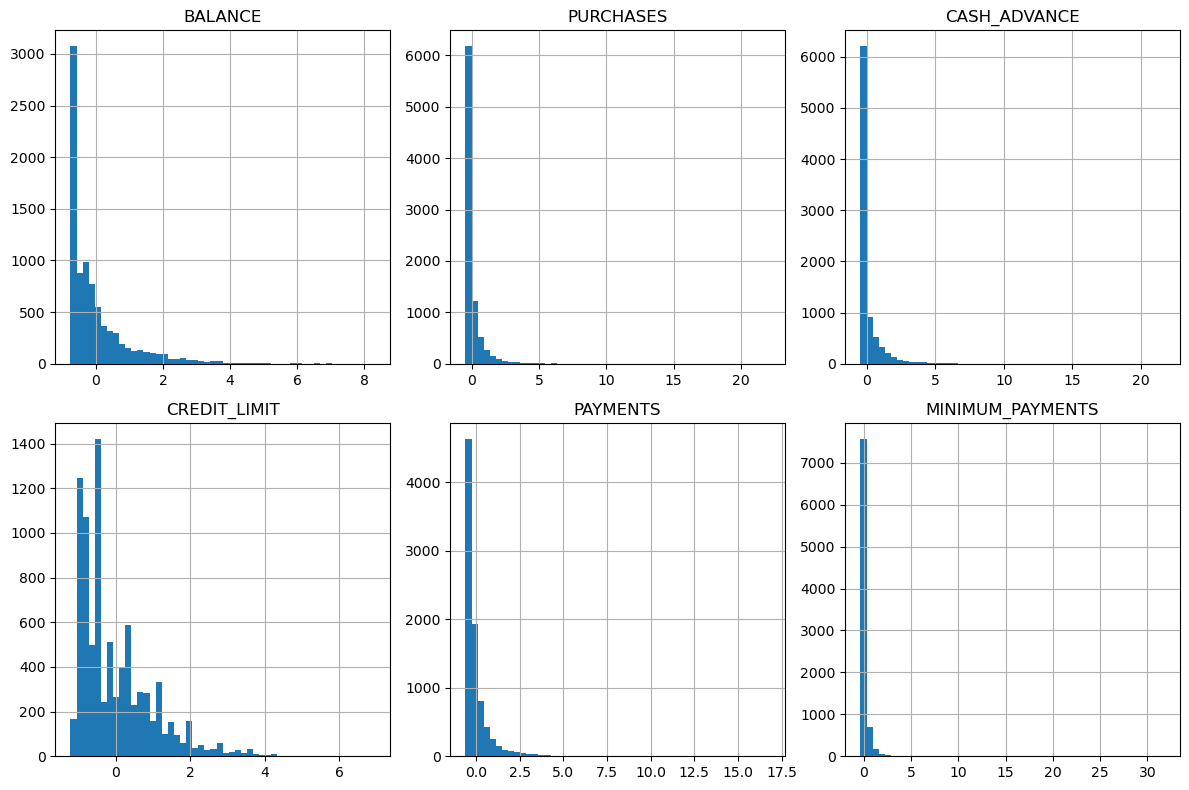

In [36]:
# Plot the distributions through histograms (all right skewed)
df_scaled.hist(figsize=(12, 8), bins=50, layout=(2, 3))

plt.tight_layout()
plt.show()

Based on the histograms, all features are right skewed and based from the descriptive statistics earlier, all features contain potential outliers.

***Produce a correlation heatmap. Write a short paragraph on what relationships you observe and what customer groups you might expect to find.***

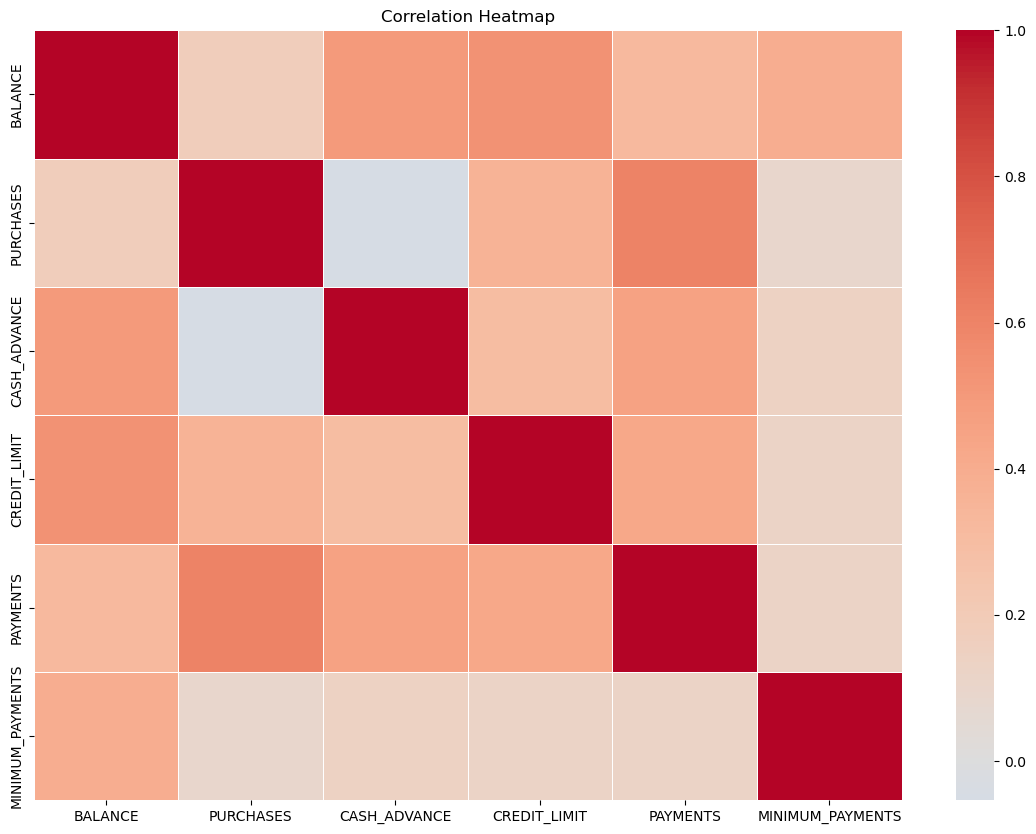

In [37]:
# Create correlation heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    df_scaled.corr(),
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

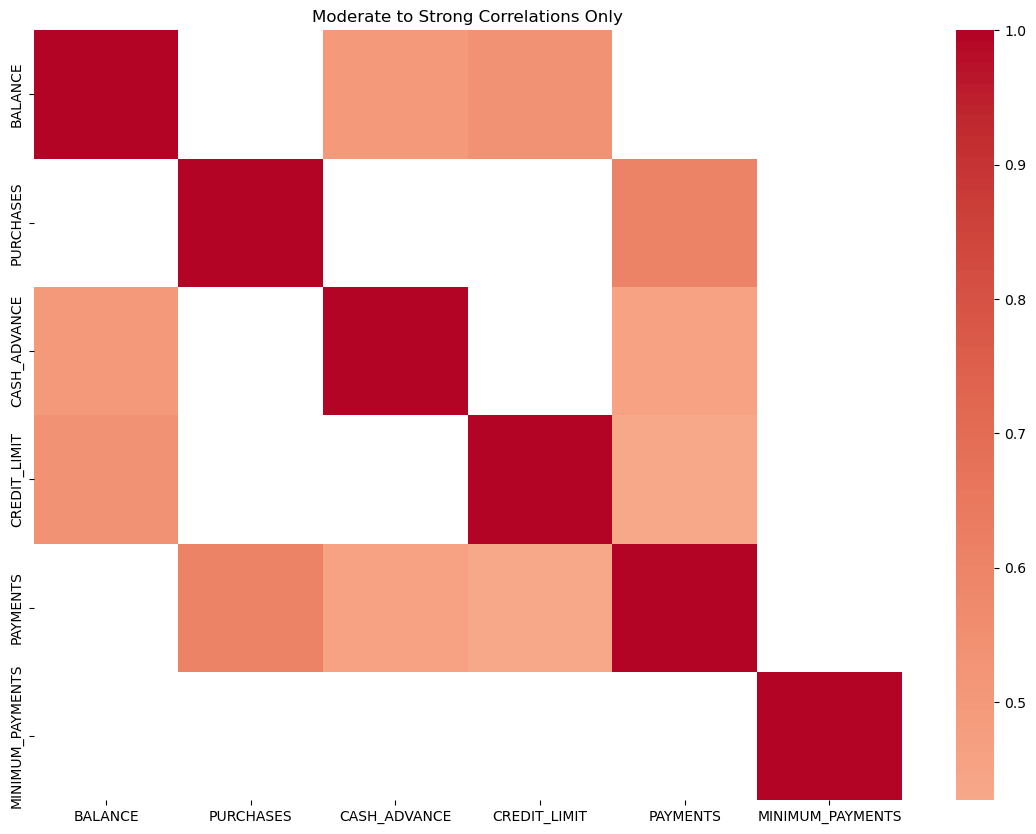

In [38]:
# filter the heatmap for readability
corr = df_scaled.corr()

mask = np.abs(corr) < 0.4  # hides all weak, very weak, and no correlation

plt.figure(figsize=(14, 10))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0)
plt.title("Moderate to Strong Correlations Only")
plt.show()

Since weak to no correlation was filtered out, we can see that BALANCE & CASH_ADVANCE, BALANCE & CREDIT_LIMIT, PURCHASES & PAYMENTS, CASH_ADVANCE & PAYMENTS, CREDIT_LIMIT & PAYMENTS are moderate to highly correlated. We may expect to see customer groups such as frequent credit card users, heavy spenders with high payment activities, and low-activity or conservative users.

## **Part 3 — DBSCAN**

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** is a clustering algorithm that groups data points based on density rather than distance to a centroid. It identifies clusters as regions of high point concentration separated by areas of low density, while explicitly labeling sparse points as noise or outliers. This makes DBSCAN particularly suitable for real-world datasets with irregular cluster shapes and the presence of anomalies. In this study, DBSCAN is applied to selected credit card usage features to uncover natural customer segments and detect atypical financial behavior.


### **Part 3A — k-distance Plot**

In [40]:
X_scaled = df_scaled.values

# Use min_samples = 5
k = 5

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances to the 5th nearest neighbor
k_distances = np.sort(distances[:, k - 1])

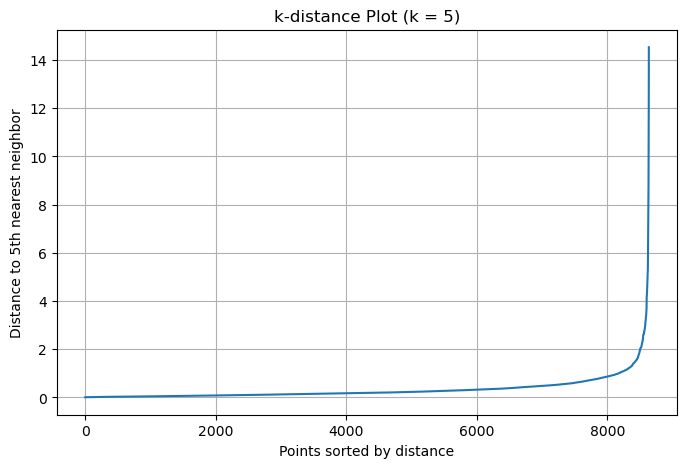

In [42]:
# Plot k-distance graph
plt.figure(figsize=(8,5))
plt.plot(k_distances)
plt.title("k-distance Plot (k = 5)")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance to 5th nearest neighbor")
plt.grid(True)
plt.show()

**Insight:**
- The k-distance plot shows a clear elbow around eps ≈ 1.0, where the curve transitions from a gradual increase to a sharp rise. This point marks the boundary between dense regions (clusters) and sparse regions (noise).
- Points before the elbow belong to well-defined clusters, while points after the elbow represent outliers or low-density areas.
- The presence of a distinct elbow indicates a suitable density threshold, supporting the choice of eps = 1.0 for effective cluster formation while limiting noise.

### **Part 3B — Test Multiple eps Values**

In [47]:
eps_values = [0.5, 0.8, 1.0, 1.2]

results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_points = np.sum(labels == -1)
    noise_percent = (noise_points / len(labels)) * 100

    results.append([eps, n_clusters, noise_points, noise_percent])

eps_results = pd.DataFrame(results, columns=["eps", "clusters_found", "noise_points", "noise_percent"])
eps_results

,eps,clusters_found,noise_points,noise_percent
0,0.5,9,1206,13.964799
1,0.8,4,557,6.449745
2,1.0,4,309,3.578045
3,1.2,4,221,2.559055


**Interpretation:**  

The k-distance plot shows an elbow at **eps ≈ 1.0**, indicating a suitable clustering threshold.

At **eps = 0.5**, the model over-segments the data (9 clusters, 13.96% noise). As eps increases to **0.8, 1.0, and 1.2**, clusters stabilize at 4 while noise decreases, showing improved structure capture.

Although **eps = 1.2** has the lowest noise (2.56%), it risks merging clusters. Thus, **eps = 1.0** is optimal, balancing stable clusters (4) and moderate noise (3.58%) without over-merging.

**Final parameters:**
* eps = 1.0
* min_samples = 5

### **Part 3C — Final Parameter Selection**

In [49]:
# Final chosen parameters
final_eps = 1.0
final_min_samples = 5

dbscan_final = DBSCAN(eps=final_eps, min_samples=final_min_samples)
labels = dbscan_final.fit_predict(X_scaled)

# Add cluster labels to the cleaned dataset
df_dbscan = df_select.copy()
df_dbscan["Cluster"] = labels

df_dbscan.head()

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,Cluster
0,40.900749,95.40,0.000000,1000.0,201.802084,139.509787,0
1,3202.467416,0.00,6442.945483,7000.0,4103.032597,1072.340217,0
2,2495.148862,773.17,0.000000,7500.0,622.066742,627.284787,0
4,817.714335,16.00,0.000000,1200.0,678.334763,244.791237,0
5,1809.828751,1333.28,0.000000,1800.0,1400.057770,2407.246035,0


**Interpretation:**
- Cluster 0 represents active credit card users with moderate to high balances and consistent payment activity. Most customers rely on purchases rather than cash advances, indicating typical transactional behavior.

**Key Insights:**

- Mixed spending levels, indicating a broad user base
- Low cash advance usage, suggesting lower risk behavior
- Strong payment activity, showing active credit management
- Wide credit limit range, covering standard to higher-tier users
- Some extreme values present but not dominant

### **Part 3D — Validation Metrics (Non-noise Points Only)**

In [50]:
# Remove noise points (-1) before computing validation metrics
mask = labels != -1
X_non_noise = X_scaled[mask]
labels_non_noise = labels[mask]

print("Number of non-noise points:", len(labels_non_noise))
print("Number of clusters (excluding noise):", len(set(labels_non_noise)))

Number of non-noise points: 8327
Number of clusters (excluding noise): 4


**Insight:** The model identifies **4 stable clusters** from **8,327 non-noise points**, indicating strong underlying customer segmentation with minimal outliers.

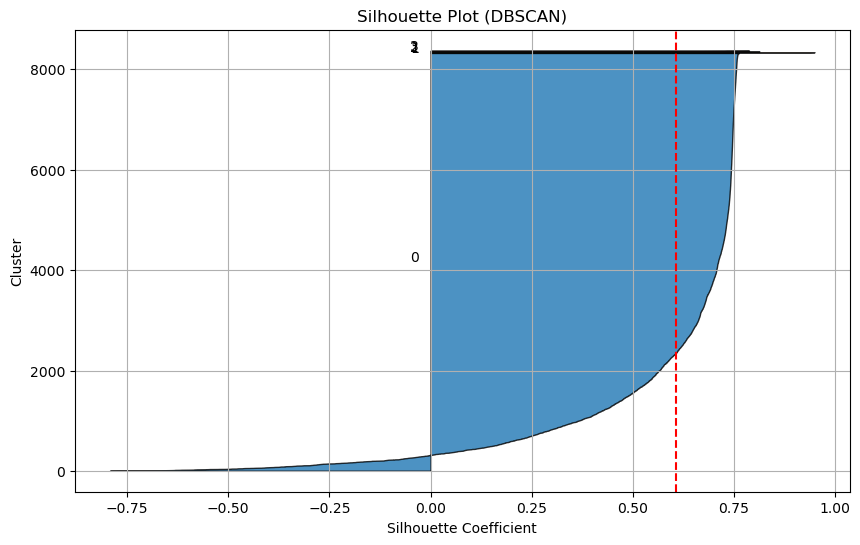

In [64]:
plt.style.use('default')

plt.figure(figsize=(10,6))

y_lower = 10
n_clusters = len(np.unique(labels_non_noise))

for i in np.unique(labels_non_noise):
    vals = silhouette_vals[labels_non_noise == i]
    vals.sort()
    
    size = len(vals)
    y_upper = y_lower + size
    
    color = cm.tab10(i % 10)  # stronger distinct colors
    
    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, vals,
        color=color,
        edgecolor='black',
        alpha=0.8
    )
    
    plt.text(-0.05, y_lower + size / 2, str(i))
    
    y_lower = y_upper + 10

plt.axvline(x=silhouette, color="red", linestyle="--")
plt.title("Silhouette Plot (DBSCAN)")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Cluster")

plt.grid(True)
plt.show()

**Insight:**
- The silhouette plot shows that the majority of data points have positive silhouette values, with most clustered between 0.2 and 0.8, indicating that points are generally well matched to their assigned clusters and reasonably separated from other clusters.
- There is a small portion of points with near-zero or negative values, suggesting some overlap or borderline assignments, but these are minimal compared to the overall distribution.

In [57]:
# Compute validation metrics only if there are at least 2 clusters
if len(set(labels_non_noise)) > 1:
    silhouette = silhouette_score(X_non_noise, labels_non_noise)
    davies_bouldin = davies_bouldin_score(X_non_noise, labels_non_noise)
    calinski_harabasz = calinski_harabasz_score(X_non_noise, labels_non_noise)

    print("Silhouette Score:", silhouette)
    print("Davies-Bouldin Index:", davies_bouldin)
    print("Calinski-Harabasz Index:", calinski_harabasz)
else:
    print("Validation metrics cannot be computed because fewer than 2 clusters remain after excluding noise.")

Silhouette Score: 0.6075817616479003
Davies-Bouldin Index: 0.31571432841903513
Calinski-Harabasz Index: 115.34379367450556


**Interpretations:**
1. **Sillhouette Score (0.608):**
   - Indicates good cluster separation and cohesion. Values above 0.5 suggest that data points are well matched within their clusters and distinct from others.
2. **Davies-Bouldin Index (0.316):**
   - Low value indicates compact and well-separated clusters. Closer to 0 is better, so this reflects strong clustering quality.
3. **Calinski-Harabasz Index (115.34):**
   - Relatively high value, indicating good between-cluster separation and within-cluster cohesion.

### **Part 3D — Cluster Profiling**

In [52]:
# Mean profile of each non-noise cluster
cluster_profile = df_dbscan[df_dbscan["Cluster"] != -1].groupby("Cluster").mean()
cluster_profile

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS
Cluster,,,,,,
0,1434.190410,854.046562,851.408066,4252.217051,1446.768200,685.520063
1,3174.697154,343.016000,97.346080,2950.000000,382.222498,27004.975174
2,10103.936531,4710.246000,57.823561,14600.000000,2779.358193,3030.948601
3,15257.162058,620.006000,4194.126786,18100.000000,3314.551088,4055.850661


**Insights:**
- **Cluster 0:** Moderate users with balanced purchases and cash advances; typical, average behavior
- **Cluster 1:** Low spenders with very high minimum payments; indicates potential financial strain
- **Cluster 2:** High-value users with high purchases, high limits, and strong payments; disciplined and profitable
- **Cluster 3:** High-balance users with heavy cash advance usage; liquidity-driven and higher risk

In [53]:
# Profile of noise points
noise_profile = df_dbscan[df_dbscan["Cluster"] == -1].describe()
noise_profile

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,Cluster
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.0
mean,5710.383523,5593.675016,4812.457900,11424.271845,10850.598467,5163.870082,-1.0
std,3804.364824,7763.288584,6331.258809,5172.923061,8759.512316,9163.992917,0.0
min,4.382924,0.000000,0.000000,1200.000000,46.969049,16.950090,-1.0
25%,2643.343414,283.880000,0.000000,7500.000000,4557.360839,1055.547896,-1.0
50%,5066.461251,3214.190000,2654.856157,11500.000000,8754.779769,2154.909881,-1.0
75%,8161.848730,7066.080000,7378.253685,15000.000000,14290.996270,5114.110493,-1.0
max,19043.138560,49039.570000,47137.211760,30000.000000,50721.483360,76406.207520,-1.0


**Insights:**  

***Noise Points (Cluster -1):***
- Extremely high variability across all features (large std and wide ranges)
- Very high balances, purchases, cash advances, and payments on average
- Contains both very low and extremely high values → highly inconsistent behavior
- Represents customers with unusual or irregular credit usage patterns
- Likely includes outliers such as extreme spenders or highly leveraged users

### **Part 3E — Cluster Sizes**

In [54]:
# Count the number of points in each cluster, including noise
cluster_counts = df_dbscan["Cluster"].value_counts().sort_index()
cluster_counts

Cluster
-1     309
 0    8312
 1       5
 2       5
 3       5
Name: count, dtype: int64

**Insight:**
- The clustering is highly imbalanced, with most customers in one main cluster (Cluster 0), indicating similar behavior across the majority. The very small clusters represent rare or niche patterns, while noise points capture outliers with irregular behavior.


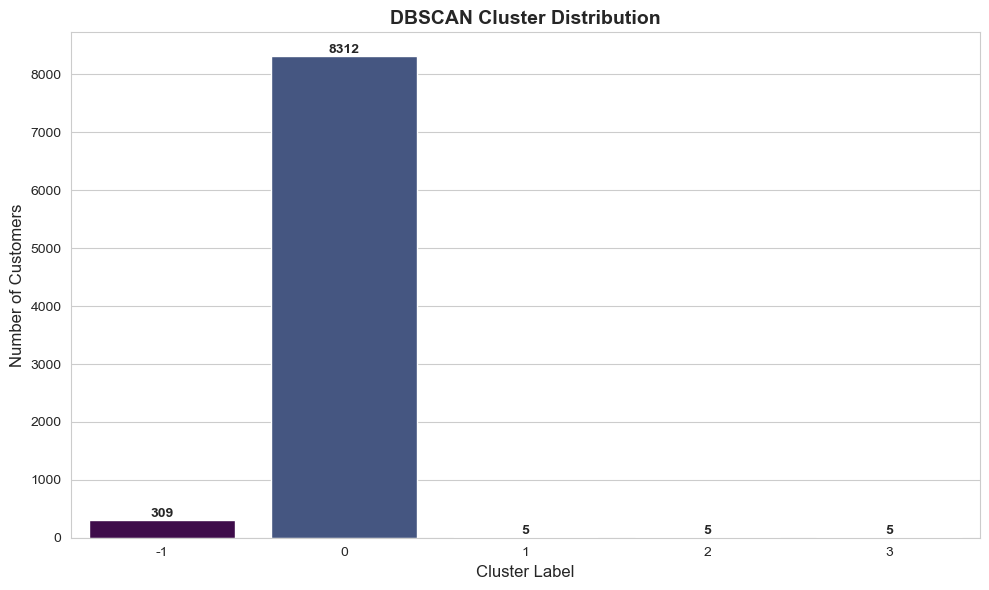

In [66]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

ax = sns.countplot(
    x="Cluster",
    data=df_dbscan,
    order=sorted(df_dbscan["Cluster"].unique()),
    hue="Cluster",          # add this
    palette="viridis",
    legend=False            # remove duplicate legend
)

# Add labels on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

plt.title("DBSCAN Cluster Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Cluster Label", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.tight_layout()
plt.show()

**Insight:**
- The distribution is highly skewed, with Cluster 0 containing the vast majority of customers (8312)
- Noise points (-1 = 309) represent a small but notable group of outliers
- Clusters 1, 2, and 3 (5 each) are extremely small, indicating rare or niche behaviors